# Scenario 1 — $1,000 lump sum

Validation and exploration for the lump-sum scenario: invest $1,000 at the start of each rolling N-year window. Reads the parquet built by `src/ingest.py` and uses the same `rolling_window_returns` helper that `src/scenarios/lump_sum.py` calls.

Run from the project root: `jupyter notebook notebooks/01_lump_sum.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis import rolling_window_returns

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 4)

## Load the data

In [ ]:
df = pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_returns.parquet').set_index('date').sort_index()
print(f'Rows: {len(df):,}')
print(f'Span: {df.index.min().date()} to {df.index.max().date()}')
print(df.head())

#print((1+df.iloc[0,0])/(1+(df.iloc[0,4]))-1)

    


Rows: 1,195
Span: 1926-08-31 to 2026-03-31
            nominal_return  real_return     rf     cpi  inflation
date                                                             
1926-08-31          0.0289       0.0348 0.0025 17.4000    -0.0057
1926-09-30          0.0061       0.0004 0.0023 17.5000     0.0057
1926-10-31         -0.0295      -0.0350 0.0032 17.6000     0.0057
1926-11-30          0.0285       0.0227 0.0031 17.7000     0.0057
1926-12-31          0.0290       0.0290 0.0028 17.7000     0.0000
0.034813218390804535


## Sanity check: long-run CAGRs

Compounded annualized return over the full history. Expected ballpark:
**~9.5–10.5% nominal**, **~6.5–7.5% real**.

If you see ~0.1% or ~1000%, it's a percent-vs-decimal unit bug.

In [3]:
def full_history_cagr(returns: pd.Series) -> float:
    n_months = len(returns)
    terminal = np.exp(np.log1p(returns).sum())
    return terminal ** (12 / n_months) - 1

print(f'Nominal CAGR: {full_history_cagr(df["nominal_return"]):.2%}')
print(f'Real CAGR:    {full_history_cagr(df["real_return"]):.2%}')

Nominal CAGR: 10.20%
Real CAGR:    6.99%


## Sanity check: known months

October 1987 should be around −21.5% nominal; March 2020 around −13%.

In [4]:
df.loc[['1987-10-31', '2020-03-31'], ['nominal_return', 'real_return', 'inflation']]

,nominal_return,real_return,inflation
date,,,
1987-10-31,-0.2259,-0.2279,0.0026
2020-03-31,-0.1325,-0.1306,-0.0022


## 10-year rolling CAGRs

In [5]:
nom10 = rolling_window_returns(df['nominal_return'], years=10)
real10 = rolling_window_returns(df['real_return'], years=10)

print(f'10-year windows: {len(nom10):,}')
nom10.head()

10-year windows: 1,076


,end_date,terminal_value,cagr
date,,,
1926-08-31,1936-07-31,1.6773,0.0531
1926-09-30,1936-08-31,1.6466,0.0511
1926-10-31,1936-09-30,1.6527,0.0515
1926-11-30,1936-10-31,1.8242,0.0620
1926-12-31,1936-11-30,1.8316,0.0624


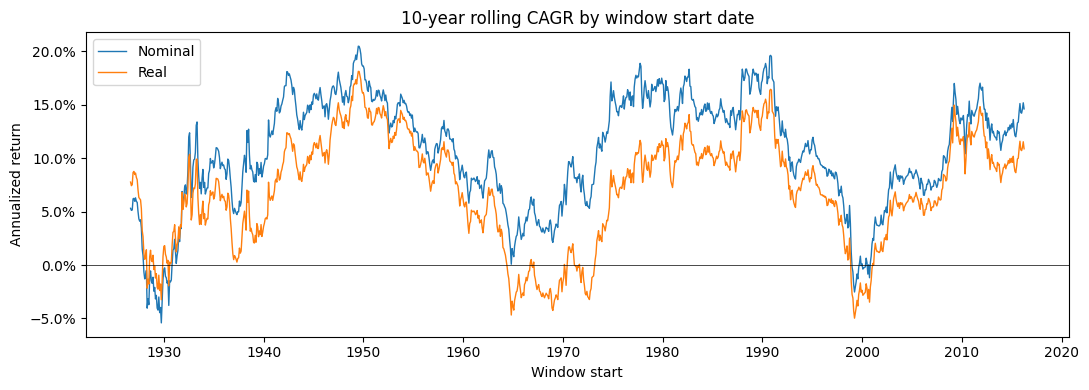

In [6]:
fig, ax = plt.subplots()
ax.plot(nom10.index, nom10['cagr'], label='Nominal', linewidth=1)
ax.plot(real10.index, real10['cagr'], label='Real', linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_title('10-year rolling CAGR by window start date')
ax.set_xlabel('Window start')
ax.set_ylabel('Annualized return')
ax.legend()
plt.tight_layout()
plt.show()

## Distribution of 10-year CAGRs

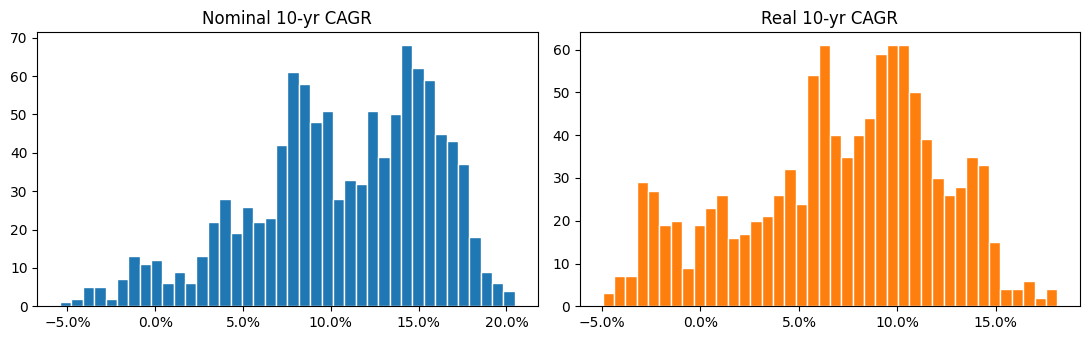

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(nom10['cagr'], bins=40, edgecolor='white')
axes[0].set_title('Nominal 10-yr CAGR')
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].hist(real10['cagr'], bins=40, edgecolor='white', color='C1')
axes[1].set_title('Real 10-yr CAGR')
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [8]:
nom_neg = (nom10['cagr'] <= 0).mean()
real_neg = (real10['cagr'] <= 0).mean()
print(f'Nominal 10-yr windows with return <= 0: {nom_neg:.2%} ({(nom10["cagr"] <= 0).sum():,} of {len(nom10):,})')
print(f'Real 10-yr windows with return <= 0:    {real_neg:.2%} ({(real10["cagr"] <= 0).sum():,} of {len(real10):,})')

Nominal 10-yr windows with return <= 0: 4.65% (50 of 1,076)
Real 10-yr windows with return <= 0:    12.45% (134 of 1,076)


## Best and worst 10-year decades

In [9]:
print('Best nominal 10-year windows:')
print(nom10.nlargest(5, 'cagr')[['end_date', 'cagr', 'terminal_value']])
print('\nWorst nominal 10-year windows:')
print(nom10.nsmallest(5, 'cagr')[['end_date', 'cagr', 'terminal_value']])

Best nominal 10-year windows:
             end_date   cagr  terminal_value
date                                        
1949-06-30 1959-05-31 0.2048          6.4418
1949-07-31 1959-06-30 0.2045          6.4290
1949-08-31 1959-07-31 0.2020          6.2951
1949-05-31 1959-04-30 0.1989          6.1367
1949-09-30 1959-08-31 0.1974          6.0578

Worst nominal 10-year windows:
             end_date    cagr  terminal_value
date                                         
1929-09-30 1939-08-31 -0.0541          0.5732
1929-07-31 1939-06-30 -0.0445          0.6340
1929-05-31 1939-04-30 -0.0422          0.6499
1928-04-30 1938-03-31 -0.0403          0.6624
1929-04-30 1939-03-31 -0.0403          0.6630


In [10]:
print('Best real 10-year windows:')
print(real10.nlargest(5, 'cagr')[['end_date', 'cagr', 'terminal_value']])
print('\nWorst real 10-year windows:')
print(real10.nsmallest(5, 'cagr')[['end_date', 'cagr', 'terminal_value']])

Best real 10-year windows:
             end_date   cagr  terminal_value
date                                        
1949-06-30 1959-05-31 0.1812          5.2868
1949-07-31 1959-06-30 0.1810          5.2802
1949-08-31 1959-07-31 0.1772          5.1094
1949-05-31 1959-04-30 0.1760          5.0575
1949-03-31 1959-02-28 0.1735          4.9529

Worst real 10-year windows:
             end_date    cagr  terminal_value
date                                         
1999-03-31 2009-02-28 -0.0497          0.6005
1964-10-31 1974-09-30 -0.0468          0.6194
1999-04-30 2009-03-31 -0.0451          0.6304
1999-02-28 2009-01-31 -0.0428          0.6456
1968-12-31 1978-11-30 -0.0425          0.6476


## $1,000 in 1980 — and at every other start date

The original motivating question: if I had invested $1,000 on a given month,
what would I have ten years later? Plot the answer across the whole history.

In [11]:
row = nom10.loc['1980-01-31']
print(f'$1,000 invested at start of {row.name.date()}:')
print(f'  Terminal value at {row["end_date"].date()}: ${row["terminal_value"] * 1000:,.2f}')
print(f'  Annualized return: {row["cagr"]:.2%}')

$1,000 invested at start of 1980-01-31:
  Terminal value at 1989-12-31: $4,754.60
  Annualized return: 16.87%


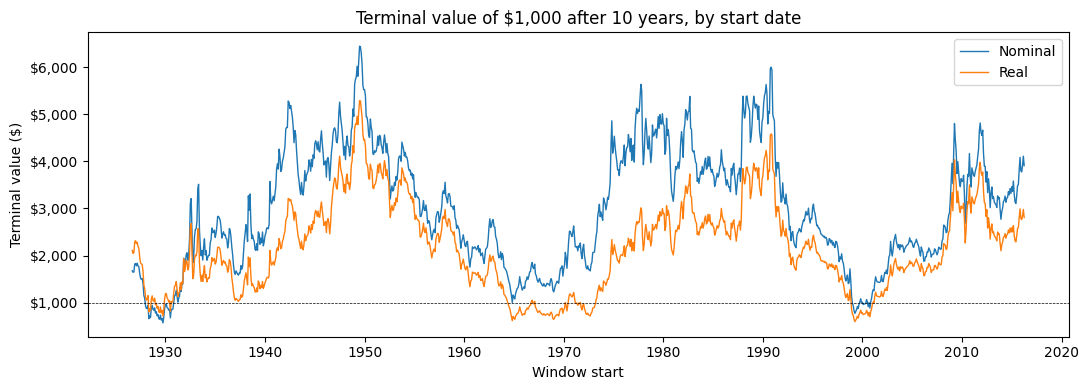

In [12]:
fig, ax = plt.subplots()
ax.plot(nom10.index, nom10['terminal_value'] * 1000, label='Nominal', linewidth=1)
ax.plot(real10.index, real10['terminal_value'] * 1000, label='Real', linewidth=1)
ax.axhline(1000, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Terminal value of $1,000 after 10 years, by start date')
ax.set_xlabel('Window start')
ax.set_ylabel('Terminal value ($)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()